# Analysis of NTK Eigenvalue and Eigenvector Distributions

We analyze the distributions of eigenvalues and eigenvectors of the NTK matrix.

In [ ]:
import os
import numpy as np
import jax.numpy as jnp

import matplotlib.pyplot as plt
from tqdm import tqdm
import csv  # we use csv instead of pandas
from collections import defaultdict  # we use defaultdict for grouping
import json  # we add json for storing test results
import seaborn as sns  # we use seaborn for enhanced heatmap visualizations

In [ ]:
import dotenv
dotenv.load_dotenv()
PROJECT_ROOT = os.getenv("PROJECT_ROOT")
PATH_TO_DATA = os.path.join(PROJECT_ROOT, "experiments", "data", "eigen")
PATH_TO_PLOTS = os.path.join(PROJECT_ROOT, "experiments", "plots", "eigen", "entropy")

# we create necessary directories
os.makedirs(PATH_TO_PLOTS, exist_ok=True)

In [ ]:
def get_config_from_filename(filename):
    """we extract configuration parameters from filename"""
    parts = filename.replace(".npy", "").split("_")
    N = int(parts[-4][1:])
    D = int(parts[-3][1:])
    M = int(parts[-2][1:])
    L = int(parts[-1][1:])
    return N, D, M, L

def load_experiment_data(N, D_IN, M, L):
    """we load eigenvalues and eigenvectors data for a specific configuration"""
    filename_eigenvalues = f"values/ntk_eigenvalues_N{N}_D{D_IN}_M{M}_L{L}.npy"
    filename_eigenvectors = f"vectors/ntk_eigenvectors_N{N}_D{D_IN}_M{M}_L{L}.npy"
    
    eigenvalues_data = np.load(os.path.join(PATH_TO_DATA, filename_eigenvalues), allow_pickle=True).item()
    eigenvectors_data = np.load(os.path.join(PATH_TO_DATA, filename_eigenvectors), allow_pickle=True).item()
    
    return eigenvalues_data, eigenvectors_data

In [ ]:

def get_ordinal_suffix(n):
    """we get the ordinal suffix for a number (1st, 2nd, 3rd, 4th, etc.)"""
    if 10 <= n % 100 <= 20:
        suffix = 'th'
    else:
        suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(n % 10, 'th')
    return f"{n}{suffix}"

def compute_entropy_in_eigenvector_basis(eigenvectors, eigenvector_order, N, D_IN, M, L, output_dir):
    """
    We compute the entropy of the distribution for each coordinate of a specific eigenvector order,
    but using the eigenvectors of the first experiment as the basis.
    """
    n_experiments, n_vectors, dimension = eigenvectors.shape
    
    # we use the first experiment's eigenvectors as the basis
    first_experiment_basis = eigenvectors[0, :, :] # shape (n_vectors, dimension)
    
    try: # we get the eigenvectors for the specific order from all other experiments
        selected_eigenvectors = eigenvectors[1:, eigenvector_order, :] # shape (n_experiments-1, dimension)
    except IndexError:
        print(f"Warning: Could not extract eigenvector {eigenvector_order+1} for config N{N}_D{D_IN}_M{M}_L{L}.")
        return None

    n_remaining_experiments, dimension = selected_eigenvectors.shape
    
    # we project each eigenvector onto the basis formed by first experiment's eigenvectors
    coordinates_in_basis = []
    for exp_idx in range(n_remaining_experiments):
        eigenvector = selected_eigenvectors[exp_idx, :] # current eigenvector
        
        # we compute scalar products with each basis vector
        coords = []
        for basis_idx in range(min(n_vectors, dimension-1)): # we use N-1 vectors as mentioned
            basis_vector = first_experiment_basis[basis_idx, :]
            scalar_product = np.dot(eigenvector, basis_vector)
            coords.append(scalar_product)
        
        coordinates_in_basis.append(coords)
    
    coordinates_in_basis = np.array(coordinates_in_basis) # shape (n_remaining_experiments, n_basis_vectors)
    
    # we compute entropy for each coordinate in the new basis
    coordinate_entropies = []
    n_basis_coords = coordinates_in_basis.shape[1]
    
    for i in range(n_basis_coords): # we compute entropy coordinate-wise in new basis
        coordinate_values = coordinates_in_basis[:, i]
        
        hist, bin_edges = np.histogram(coordinate_values, bins='auto', density=True)
        bin_width = bin_edges[1] - bin_edges[0]
        
        # we normalize
        probabilities = hist * bin_width
        probabilities = probabilities[probabilities > 0] # we remove zero probabilities
        
        entropy = -np.sum(probabilities * np.log2(probabilities))
        coordinate_entropies.append(entropy)
    
    return coordinate_entropies

def analyze_entropy_in_eigenvector_basis(eigenvectors, N, D_IN, M, L, output_dir):
    """
    Analyze entropy distributions using the first experiment's eigenvectors as basis.
    """
    n_experiments, n_vectors, dimension = eigenvectors.shape
    
    if n_experiments < 2:
        print(f"Warning: Need at least 2 experiments for basis analysis, got {n_experiments}")
        return None
    
    print(f"Computing entropy in eigenvector basis - N{N}_D{D_IN}_M{M}_L{L}")
    print(f"Using first experiment as basis, analyzing {n_experiments-1} remaining experiments")
    
    # we compute entropy for each eigenvector order
    all_entropies = []
    n_basis_vectors = min(n_vectors, dimension-1) # we use N-1 vectors as basis
    
    for k in range(n_vectors):
        entropies = compute_entropy_in_eigenvector_basis(eigenvectors, k, N, D_IN, M, L, output_dir)
        if entropies is not None:
            all_entropies.append(entropies)
    
    if not all_entropies:
        print("No valid entropy computations")
        return None
        
    all_entropies = np.array(all_entropies) # shape (n_vectors, n_basis_vectors)
    
    # viz creation
    plt.figure(figsize=(14, 10))
    
    # we plot entropy for each eigenvector order
    eigenvector_indices = list(range(1, len(all_entropies) + 1))
    basis_indices = list(range(1, n_basis_vectors + 1))
    
    plt.subplot(2, 2, 1)
    mean_entropies = np.mean(all_entropies, axis=1)
    std_entropies = np.std(all_entropies, axis=1)
    
    plt.errorbar(eigenvector_indices, mean_entropies, yerr=std_entropies,
                fmt='o-', capsize=5, linewidth=2, markersize=6)
    plt.title(f'Mean Entropy in Eigenvector Basis\nConfig N{N}_D{D_IN}_M{M}_L{L}')
    plt.xlabel('Eigenvector Order')
    plt.ylabel('Mean Entropy (bits)')
    plt.grid(True)
    
    plt.subplot(2, 2, 2)
    plt.imshow(all_entropies.T, aspect='auto', cmap='viridis')
    plt.colorbar(label='Entropy (bits)')
    plt.title('Entropy Heatmap (Eigenvector Basis)')
    plt.xlabel('Eigenvector Order')
    plt.ylabel('Basis Vector Index')
    
    # we plot distribution of all entropies
    plt.subplot(2, 2, 3)
    all_entropy_values = all_entropies.flatten()
    plt.hist(all_entropy_values, bins=30, alpha=0.7, density=True)
    plt.axvline(np.mean(all_entropy_values), color='red', linestyle='--', 
                label=f'Mean: {np.mean(all_entropy_values):.3f}')
    plt.title('Distribution of All Entropies')
    plt.xlabel('Entropy (bits)')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
    
    # we plot entropy vs basis vector index
    plt.subplot(2, 2, 4)
    mean_entropies_per_basis = np.mean(all_entropies, axis=0)
    std_entropies_per_basis = np.std(all_entropies, axis=0)
    
    plt.errorbar(basis_indices, mean_entropies_per_basis, yerr=std_entropies_per_basis,
                fmt='s-', capsize=5, linewidth=2, markersize=6, color='orange')
    plt.title('Mean Entropy per Basis Vector')
    plt.xlabel('Basis Vector Index')
    plt.ylabel('Mean Entropy (bits)')
    plt.grid(True)
    
    plt.tight_layout()
    
    # Save plot
    entropy_filename = os.path.join(output_dir, f'entropy_eigenvector_basis_N{N}_D{D_IN}_M{M}_L{L}.png')
    plt.savefig(entropy_filename, dpi=120, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # Print statistics
    print(f"\nEntropy Statistics in Eigenvector Basis:")
    print(f"  Overall mean entropy: {np.mean(all_entropy_values):.4f} ± {np.std(all_entropy_values):.4f} bits")
    print(f"  Max entropy: {np.max(all_entropy_values):.4f} bits")
    print(f"  Min entropy: {np.min(all_entropy_values):.4f} bits")
    print(f"  Number of basis vectors used: {n_basis_vectors}")
    
    # Find most and least random eigenvectors
    most_random_idx = np.argmax(mean_entropies)
    least_random_idx = np.argmin(mean_entropies)
    
    print(f"\nMost random eigenvector: {get_ordinal_suffix(most_random_idx + 1)}")
    print(f"  Mean entropy: {mean_entropies[most_random_idx]:.4f} ± {std_entropies[most_random_idx]:.4f} bits")
    
    print(f"\nLeast random eigenvector: {get_ordinal_suffix(least_random_idx + 1)}")
    print(f"  Mean entropy: {mean_entropies[least_random_idx]:.4f} ± {std_entropies[least_random_idx]:.4f} bits")
    
    # we test uniformity hypothesis
    theoretical_uniform_entropy = np.log2(n_experiments-1) # we approximate for uniform distribution
    print(f"\nUniformity Analysis:")
    print(f"  Theoretical uniform entropy (approx): {theoretical_uniform_entropy:.4f} bits")
    print(f"  Observed mean entropy: {np.mean(all_entropy_values):.4f} bits")
    print(f"  Difference: {np.mean(all_entropy_values) - theoretical_uniform_entropy:.4f} bits")
    
    return {
        'mean_entropies': mean_entropies,
        'std_entropies': std_entropies,
        'all_entropies': all_entropies,
        'most_random_idx': most_random_idx,
        'least_random_idx': least_random_idx,
        'n_basis_vectors': n_basis_vectors,
        'theoretical_uniform_entropy': theoretical_uniform_entropy
    }

Processing all experiment files for eigenvector basis entropy analysis...


Processing experiment files:   0%|          | 0/97 [00:00<?, ?it/s]

Computing entropy in eigenvector basis - N8_D20_M10_L8
Using first experiment as basis, analyzing 99 remaining experiments


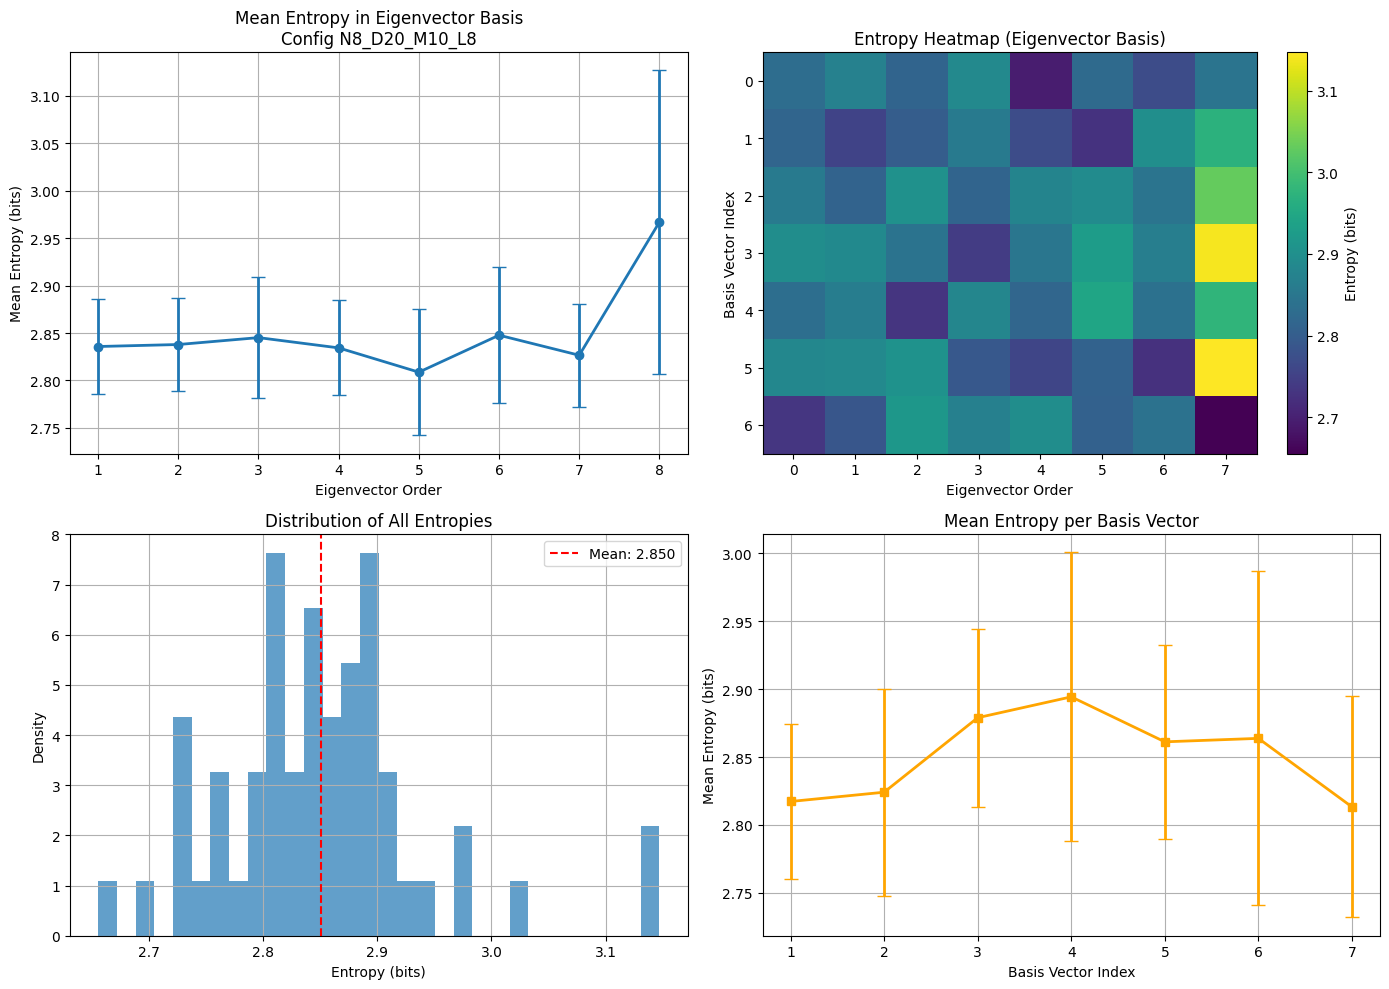

Processing experiment files:   1%|          | 1/97 [00:08<13:42,  8.57s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8504 ± 0.0908 bits
  Max entropy: 3.1472 bits
  Min entropy: 2.6553 bits
  Number of basis vectors used: 7

Most random eigenvector: 8th
  Mean entropy: 2.9669 ± 0.1599 bits

Least random eigenvector: 5th
  Mean entropy: 2.8088 ± 0.0666 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8504 bits
  Difference: -3.7789 bits


Computing entropy in eigenvector basis - N8_D20_M10_L4
Using first experiment as basis, analyzing 99 remaining experiments


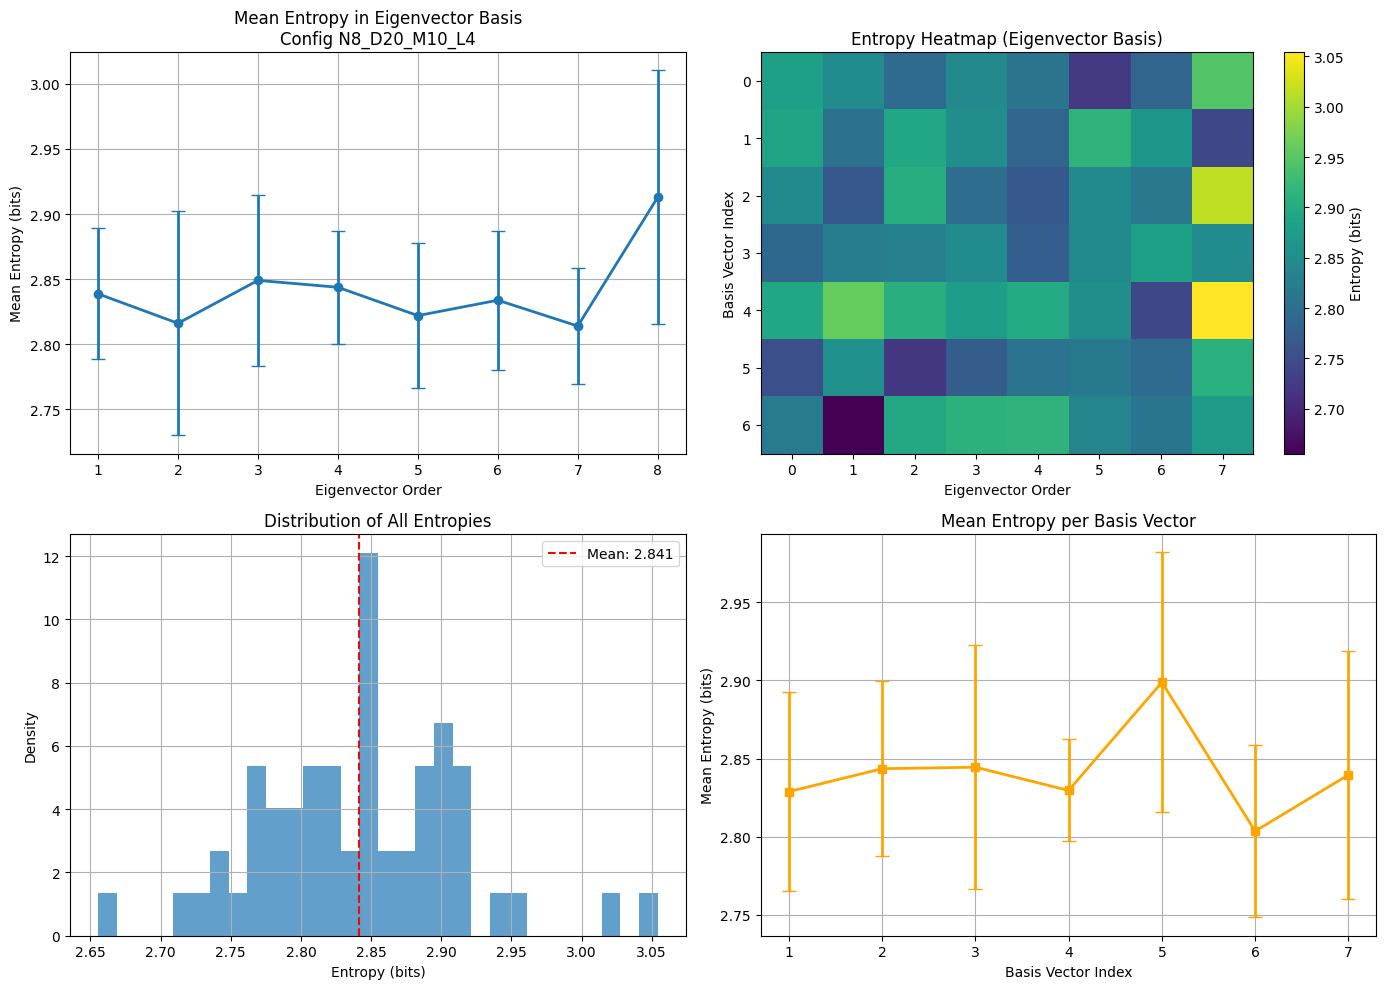

Processing experiment files:   2%|▏         | 2/97 [00:18<14:48,  9.36s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8412 ± 0.0713 bits
  Max entropy: 3.0543 bits
  Min entropy: 2.6554 bits
  Number of basis vectors used: 7

Most random eigenvector: 8th
  Mean entropy: 2.9129 ± 0.0976 bits

Least random eigenvector: 7th
  Mean entropy: 2.8138 ± 0.0443 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8412 bits
  Difference: -3.7882 bits


Computing entropy in eigenvector basis - N8_D50_M50_L6
Using first experiment as basis, analyzing 99 remaining experiments


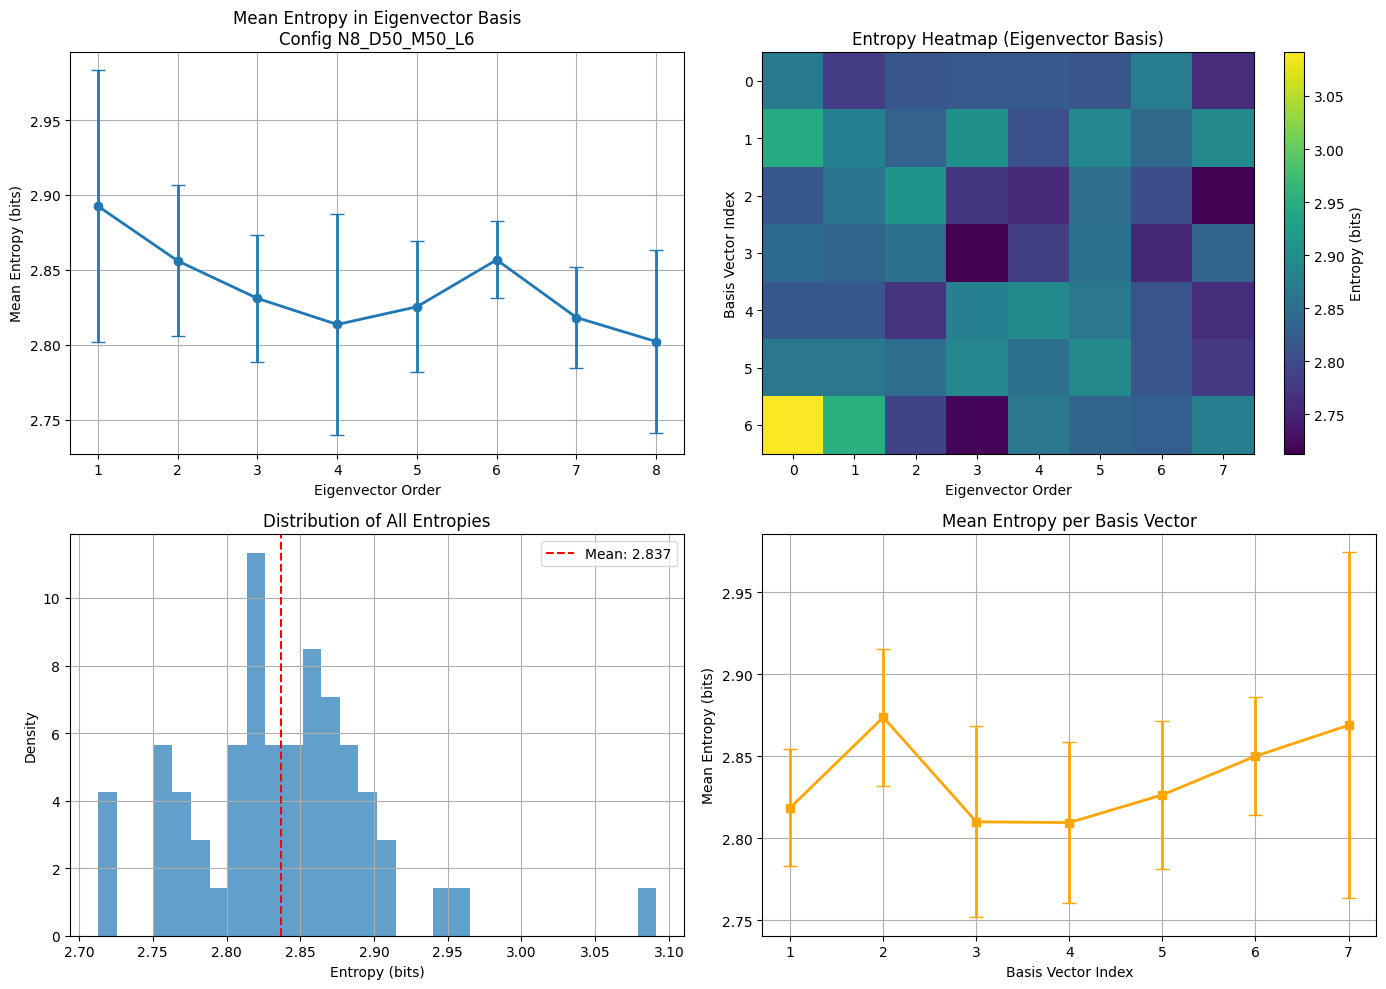

Processing experiment files:   3%|▎         | 3/97 [00:28<14:52,  9.49s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8369 ± 0.0629 bits
  Max entropy: 3.0913 bits
  Min entropy: 2.7128 bits
  Number of basis vectors used: 7

Most random eigenvector: 1st
  Mean entropy: 2.8925 ± 0.0906 bits

Least random eigenvector: 8th
  Mean entropy: 2.8020 ± 0.0614 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8369 bits
  Difference: -3.7925 bits


Computing entropy in eigenvector basis - N8_D50_M10_L2
Using first experiment as basis, analyzing 99 remaining experiments


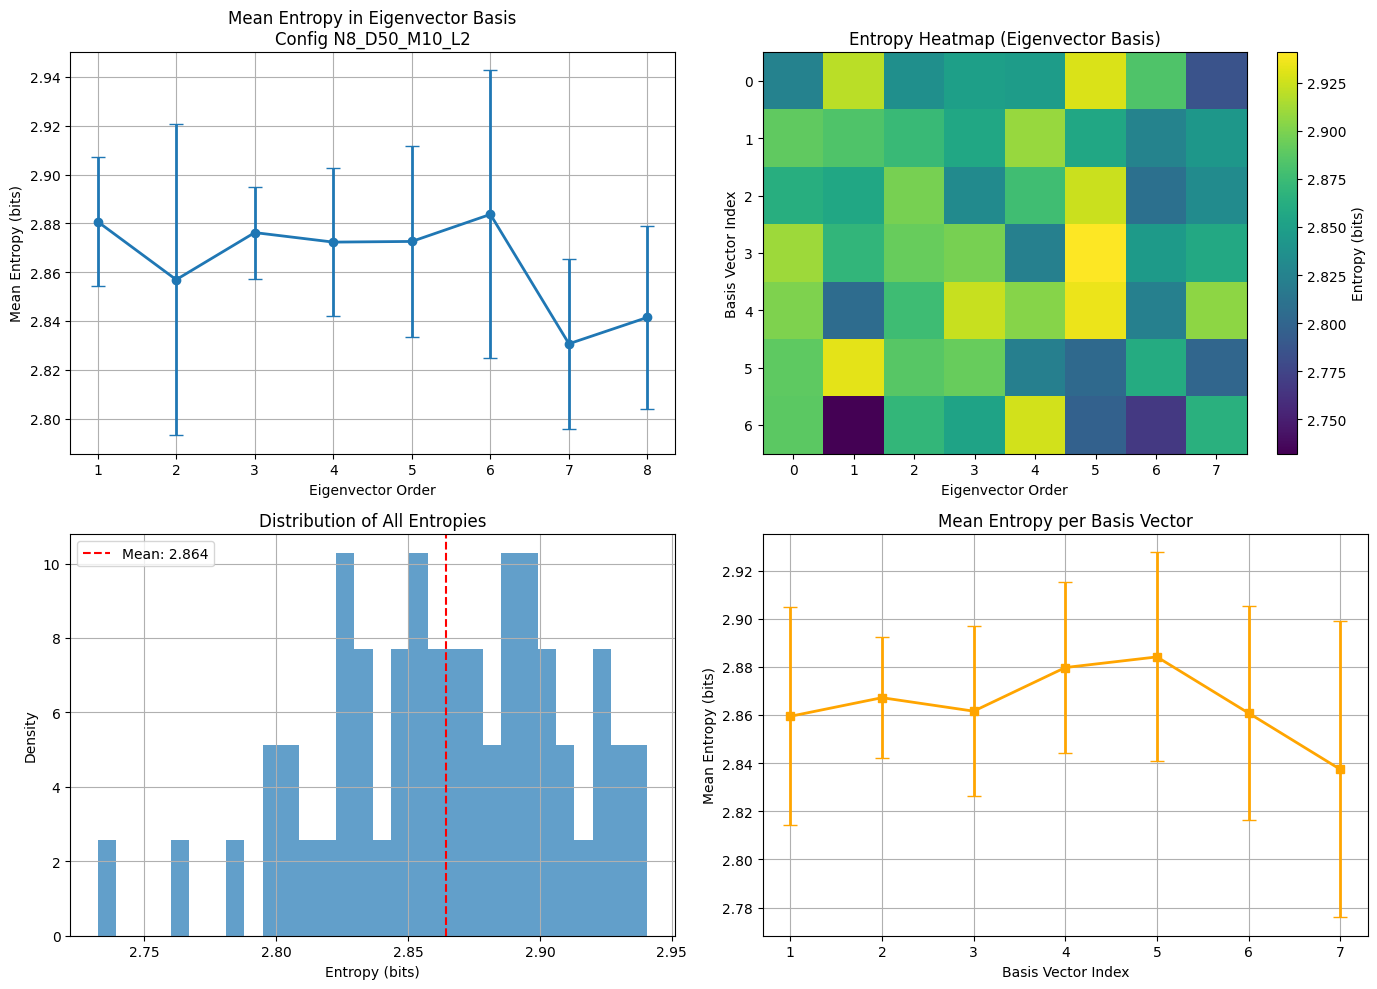

Processing experiment files:   4%|▍         | 4/97 [00:36<14:07,  9.11s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8643 ± 0.0452 bits
  Max entropy: 2.9408 bits
  Min entropy: 2.7322 bits
  Number of basis vectors used: 7

Most random eigenvector: 6th
  Mean entropy: 2.8837 ± 0.0590 bits

Least random eigenvector: 7th
  Mean entropy: 2.8306 ± 0.0348 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8643 bits
  Difference: -3.7651 bits


Computing entropy in eigenvector basis - N8_D20_M50_L4
Using first experiment as basis, analyzing 99 remaining experiments


In [ ]:
if __name__ == "__main__":
    # we process all files in the vectors directory
    files = [f for f in os.listdir(os.path.join(PATH_TO_DATA, "vectors")) if f.startswith('ntk_eigenvectors_')]
    
    # we sort files by N
    files = sorted(files, key=lambda x: get_config_from_filename(x)[0])
    
    files = files  # we process all files
    print("Processing all experiment files for eigenvector basis entropy analysis...")
    print("=" * 80)
    
    for file in tqdm(files, desc="Processing experiment files"):
        try:
            # we extract configuration from filename
            N, D_IN, M, L = get_config_from_filename(file)
            
            # we load eigenvectors data
            _, eigenvectors_data = load_experiment_data(N, D_IN, M, L)
            
            # we analyze entropy in eigenvector basis
            analyze_entropy_in_eigenvector_basis(
                eigenvectors_data['eigenvectors'].transpose(0, 2, 1), N, D_IN, M, L, PATH_TO_PLOTS
            )
            
            print("\n" + "="*50 + "\n")
            
        except Exception as e:
            print(f"Error processing {file}: {e}")
    
    print("Eigenvector basis entropy analysis complete!")